# DATA7901 — Results Summary

All figures and tables for the final report. Run with:
```bash
uv run jupyter lab notebooks/02_results.ipynb
```

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

LABEL_NAMES = ['elliptical', 'spiral', 'merger']

def load(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

print('Loaded libraries OK')

Loaded libraries OK


## 1. Main Results Table

In [2]:
results = {
    'Tabular (XGBoost)':       load('../checkpoints/tabular/test_results_full.pkl'),
    'Image (ResNet-18)':        load('../checkpoints/image/test_results_configC.pkl'),
    'Spectral (1D-CNN)':        load('../checkpoints/spectral/test_results.pkl'),
    'Fusion (best encoders)':   load('../checkpoints/fusion/test_results_bestenc.pkl'),
}

rows = []
for name, r in results.items():
    row = {
        'Model': name,
        'Macro F1': r['macro_f1'],
        'Weighted F1': r['weighted_f1'],
        'Accuracy': r['accuracy'],
    }
    for cls in LABEL_NAMES:
        pc = r['per_class'].get(cls, {})
        row[f'{cls} F1'] = round(pc.get('f1-score', 0), 3)
    rows.append(row)

df_results = pd.DataFrame(rows).set_index('Model')
df_results

,Macro F1,Weighted F1,Accuracy,elliptical F1,spiral F1,merger F1
Model,,,,,,
Tabular (XGBoost),0.7751,0.9398,0.9399,0.944,0.942,0.439
Image (ResNet-18),0.8073,0.9575,0.9548,0.963,0.958,0.501
Spectral (1D-CNN),0.5627,0.7807,0.7773,0.770,0.800,0.118
Fusion (best encoders),0.8728,0.9679,0.9672,0.972,0.968,0.679


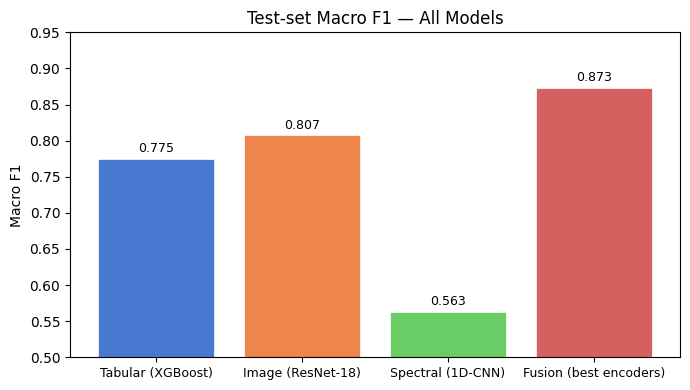

In [3]:
# Bar chart: Macro F1 per model
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']
models = list(results.keys())
f1s    = [results[m]['macro_f1'] for m in models]
bars   = ax.bar(models, f1s, color=colors, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0.5, 0.95)
ax.set_ylabel('Macro F1')
ax.set_title('Test-set Macro F1 — All Models')
ax.tick_params(axis='x', labelsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_macro_f1.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig1_macro_f1.png', dpi=200, bbox_inches='tight')
plt.show()

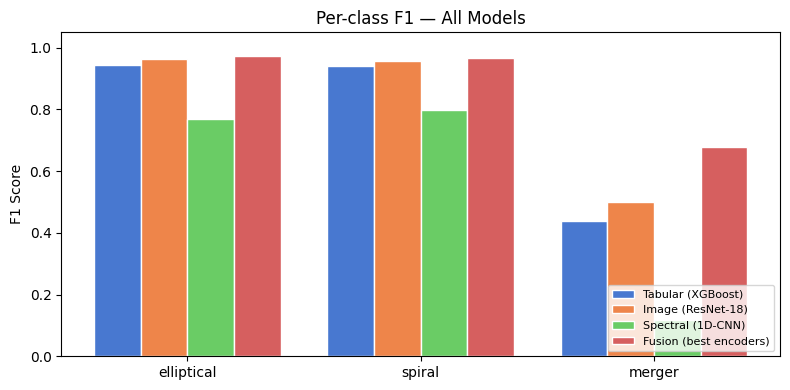

In [4]:
# Per-class F1 grouped bar chart
x     = np.arange(len(LABEL_NAMES))
width = 0.2
fig, ax = plt.subplots(figsize=(8, 4))
for i, (name, r) in enumerate(results.items()):
    vals = [r['per_class'].get(c, {}).get('f1-score', 0) for c in LABEL_NAMES]
    ax.bar(x + (i - 1.5) * width, vals, width, label=name, color=colors[i], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES)
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 — All Models')
ax.legend(fontsize=8, loc='lower right')
ax.set_ylim(0, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig2_perclass_f1.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig2_perclass_f1.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. Confusion Matrices

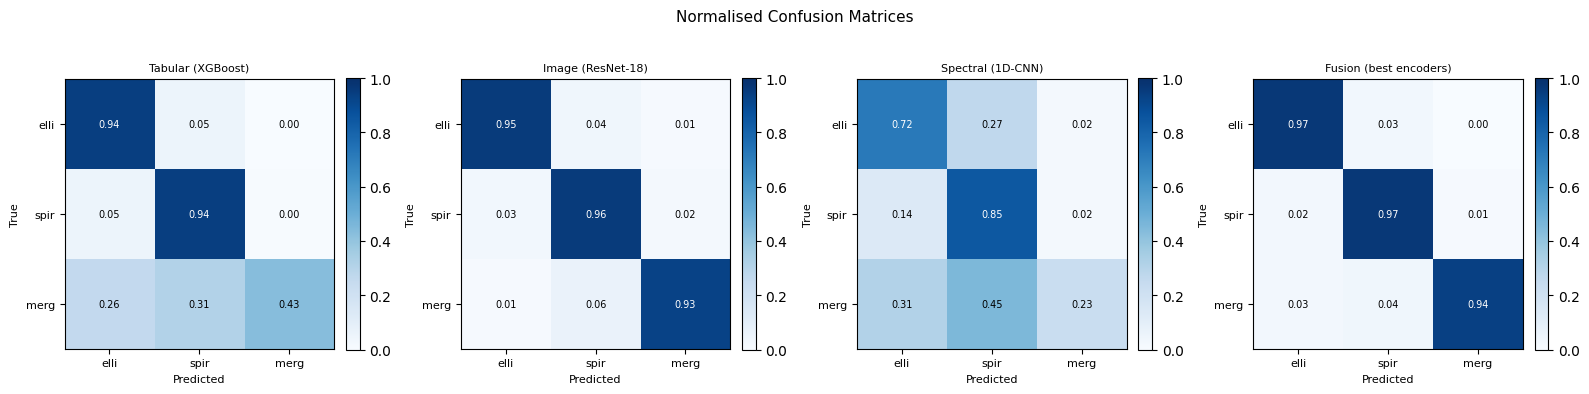

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm   = np.array(r['confusion_matrix'])
    # Normalise by row (true class)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im   = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(LABEL_NAMES))); ax.set_xticklabels([c[:4] for c in LABEL_NAMES], fontsize=8)
    ax.set_yticks(range(len(LABEL_NAMES))); ax.set_yticklabels([c[:4] for c in LABEL_NAMES], fontsize=8)
    ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('True', fontsize=8)
    ax.set_title(name, fontsize=8)
    for i in range(len(LABEL_NAMES)):
        for j in range(len(LABEL_NAMES)):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm_n[i,j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Normalised Confusion Matrices', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_confusion_matrices.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig3_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Hyperparameter Search Results

In [6]:
# XGBoost grid search
grid_df = pd.read_csv('../checkpoints/tabular/grid_search_results.csv')
print('Top 10 XGBoost configs by CV macro F1:')
grid_df.head(10)

Top 10 XGBoost configs by CV macro F1:


,n_estimators,max_depth,learning_rate,cv_macro_f1
0,300,6,0.20,0.7731
1,500,8,0.05,0.7725
2,500,6,0.10,0.7713
3,500,6,0.20,0.7681
4,300,8,0.10,0.7677
5,500,8,0.10,0.7661
6,500,4,0.20,0.7620
7,100,8,0.20,0.7619
8,300,8,0.05,0.7618
9,300,6,0.10,0.7598


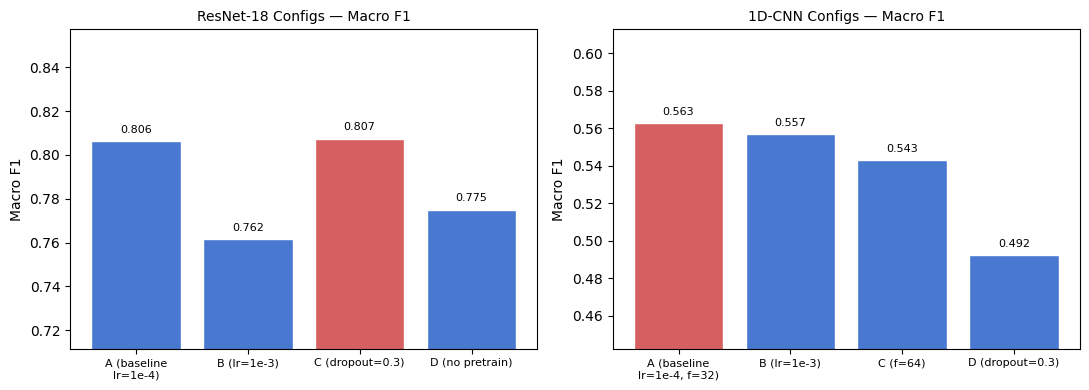

In [7]:
# ResNet-18 config comparison
img_configs = {
    'A (baseline\nlr=1e-4)':   load('../checkpoints/image/test_results.pkl'),
    'B (lr=1e-3)':              load('../checkpoints/image/test_results_configB.pkl'),
    'C (dropout=0.3)':          load('../checkpoints/image/test_results_configC.pkl'),
    'D (no pretrain)':          load('../checkpoints/image/test_results_configD.pkl'),
}

spec_configs = {
    'A (baseline\nlr=1e-4, f=32)':  load('../checkpoints/spectral/test_results.pkl'),
    'B (lr=1e-3)':                   load('../checkpoints/spectral/test_results_configB.pkl'),
    'C (f=64)':                      load('../checkpoints/spectral/test_results_configC.pkl'),
    'D (dropout=0.3)':               load('../checkpoints/spectral/test_results_configD.pkl'),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, configs, title in [
    (axes[0], img_configs,  'ResNet-18 Configs — Macro F1'),
    (axes[1], spec_configs, '1D-CNN Configs — Macro F1'),
]:
    names = list(configs.keys())
    f1s   = [configs[n]['macro_f1'] for n in names]
    best  = np.argmax(f1s)
    bar_c = ['#D65F5F' if i == best else '#4878D0' for i in range(len(names))]
    bars  = ax.bar(names, f1s, color=bar_c, edgecolor='white')
    for bar, v in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_ylim(min(f1s) - 0.05, max(f1s) + 0.05)
    ax.set_ylabel('Macro F1')
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig4_hyperparam_search.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig4_hyperparam_search.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Fusion Ablation Study

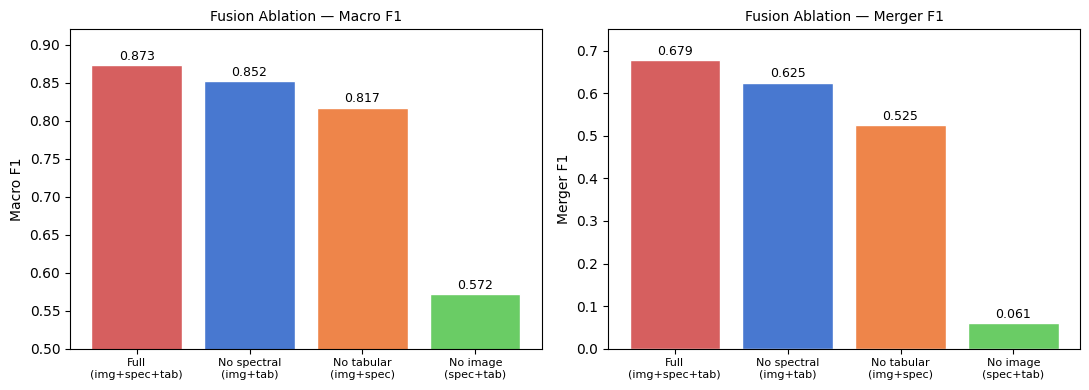

In [8]:
ablation = {
    'Full\n(img+spec+tab)':     load('../checkpoints/fusion/test_results_bestenc.pkl'),
    'No spectral\n(img+tab)':   load('../checkpoints/fusion/test_results_ablate_nospec.pkl'),
    'No tabular\n(img+spec)':   load('../checkpoints/fusion/test_results_ablate_notab.pkl'),
    'No image\n(spec+tab)':     load('../checkpoints/fusion/test_results_ablate_noimg.pkl'),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

names = list(ablation.keys())
colors_abl = ['#D65F5F', '#4878D0', '#EE854A', '#6ACC65']

# Macro F1
f1s = [ablation[n]['macro_f1'] for n in names]
bars = axes[0].bar(names, f1s, color=colors_abl, edgecolor='white')
for bar, v in zip(bars, f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0.5, 0.92)
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Fusion Ablation — Macro F1', fontsize=10)
axes[0].tick_params(axis='x', labelsize=8)

# Merger F1
mf1s = [ablation[n]['per_class'].get('merger', {}).get('f1-score', 0) for n in names]
bars = axes[1].bar(names, mf1s, color=colors_abl, edgecolor='white')
for bar, v in zip(bars, mf1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(0, 0.75)
axes[1].set_ylabel('Merger F1')
axes[1].set_title('Fusion Ablation — Merger F1', fontsize=10)
axes[1].tick_params(axis='x', labelsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_ablation.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig5_ablation.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. XGBoost Feature Importance

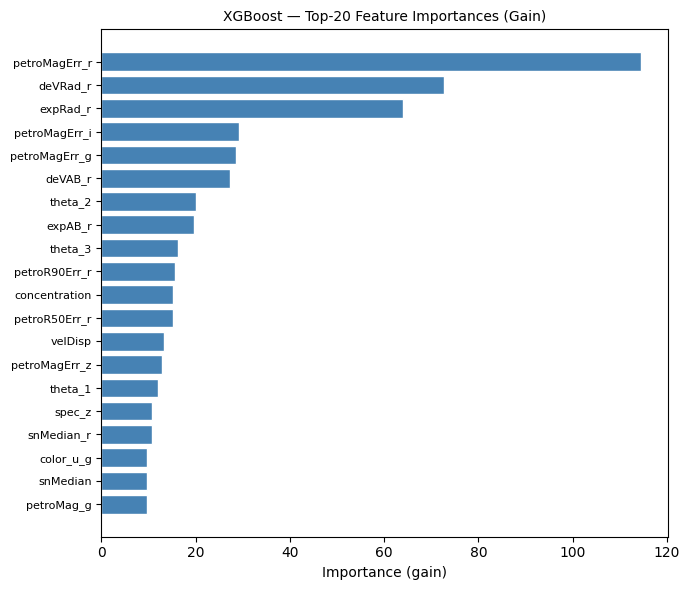

Top 10:


,feature,importance
0,petroMagErr_r,114.641678
1,deVRad_r,72.639732
2,expRad_r,63.923149
3,petroMagErr_i,29.249023
4,petroMagErr_g,28.550619
5,deVAB_r,27.382254
6,theta_2,19.963247
7,expAB_r,19.586868
8,theta_3,16.258516
9,petroR90Err_r,15.513904


In [9]:
fi = pd.read_csv('../checkpoints/tabular/feature_importance.csv')

fig, ax = plt.subplots(figsize=(7, 6))
top = fi.head(20)
ax.barh(top['feature'][::-1], top['importance'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance (gain)')
ax.set_title('XGBoost — Top-20 Feature Importances (Gain)', fontsize=10)
ax.tick_params(axis='y', labelsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6_feature_importance.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig6_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

print('Top 10:')
fi.head(10)

## 6. GradCAM Activation Maps

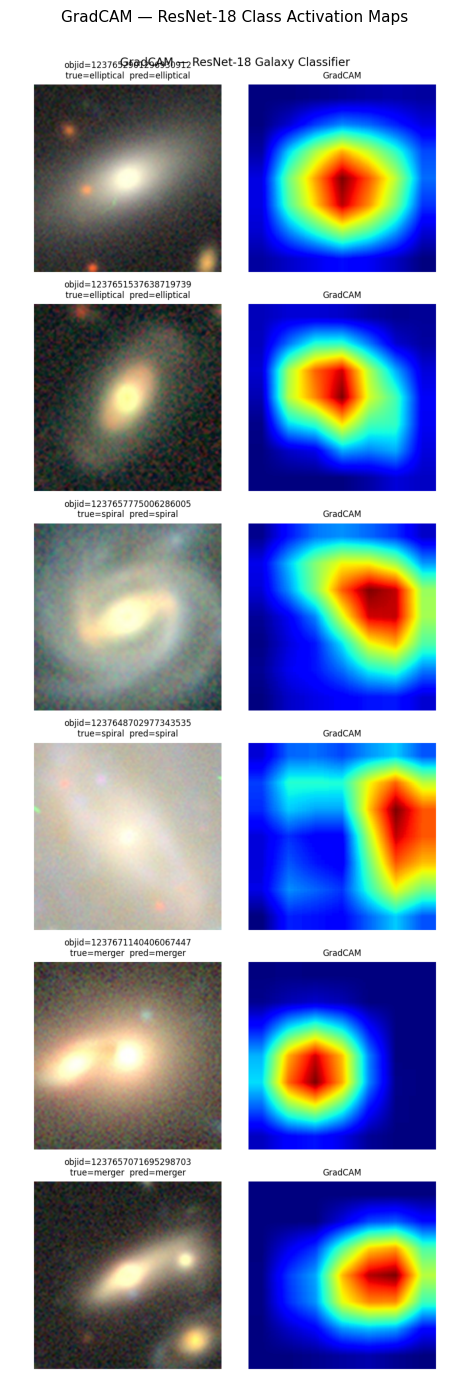

In [10]:
gradcam_img = Image.open('../checkpoints/image/gradcam_samples.png')
fig, ax = plt.subplots(figsize=(10, 14))
ax.imshow(gradcam_img)
ax.axis('off')
ax.set_title('GradCAM — ResNet-18 Class Activation Maps', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig7_gradcam.pdf', bbox_inches='tight')
plt.show()

## 7. Physical Classification (Star-forming vs Passive)

In [11]:
phys_tab  = load('../checkpoints/physical/tabular_results.pkl')

try:
    phys_spec = load('../checkpoints/physical/spectral_results.pkl')
    has_spec_phys = True
except FileNotFoundError:
    has_spec_phys = False
    print('Spectral physical results not yet available.')

print('Physical Classification Results')
print(f'Tabular macro F1 : {phys_tab["macro_f1"]:.4f}')
if has_spec_phys:
    print(f'Spectral macro F1: {phys_spec["macro_f1"]:.4f}')
    diff = phys_spec['macro_f1'] - phys_tab['macro_f1']
    print(f'Spectral advantage: {diff:+.4f}')

phys_tab

Physical Classification Results
Tabular macro F1 : 0.9997
Spectral macro F1: 0.9347
Spectral advantage: -0.0650


{'macro_f1': 0.9997,
 'weighted_f1': 0.9997,
 'accuracy': 0.9997,
 'per_class': {'star_forming': {'precision': 1.0,
   'recall': 0.999163179916318,
   'f1-score': 0.9995814148179154,
   'support': 10755.0},
  'passive': {'precision': 0.9995804978092664,
   'recall': 1.0,
   'f1-score': 0.9997902048998811,
   'support': 21445.0}},
 'confusion_matrix': [[10746, 9], [0, 21445]]}

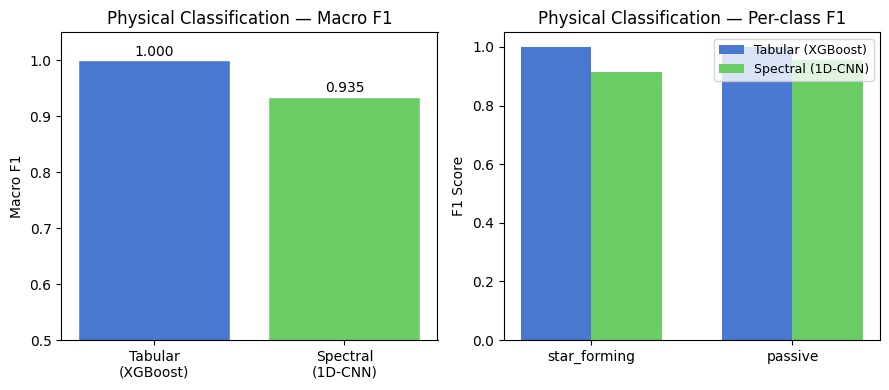

In [12]:
if has_spec_phys:
    phys_models = {'Tabular\n(XGBoost)': phys_tab, 'Spectral\n(1D-CNN)': phys_spec}
    phys_classes = ['star_forming', 'passive']
    
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    
    # Macro F1 comparison
    names = list(phys_models.keys())
    f1s   = [phys_models[n]['macro_f1'] for n in names]
    axes[0].bar(names, f1s, color=['#4878D0', '#6ACC65'], edgecolor='white')
    for i, v in enumerate(f1s):
        axes[0].text(i, v + 0.003, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    axes[0].set_ylim(0.5, 1.05)
    axes[0].set_ylabel('Macro F1')
    axes[0].set_title('Physical Classification — Macro F1')
    
    # Per-class F1
    x     = np.arange(len(phys_classes))
    width = 0.35
    for i, (name, r) in enumerate(phys_models.items()):
        vals = [r['per_class'].get(c, {}).get('f1-score', 0) for c in phys_classes]
        axes[1].bar(x + (i - 0.5) * width, vals, width,
                    label=name.replace('\n', ' '), color=['#4878D0', '#6ACC65'][i])
    axes[1].set_xticks(x); axes[1].set_xticklabels(phys_classes)
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Physical Classification — Per-class F1')
    axes[1].legend(fontsize=9)
    
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'fig8_physical.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / 'fig8_physical.png', dpi=200, bbox_inches='tight')
    plt.show()

## 8. Complete Results Summary

In [13]:
# Extended summary table
summary_rows = []
all_models = [
    ('Tabular (XGBoost, default)',     '../checkpoints/tabular/test_results.pkl'),
    ('Tabular (XGBoost, grid search)', '../checkpoints/tabular/test_results_full.pkl'),
    ('Image (ResNet-18 config A)',     '../checkpoints/image/test_results.pkl'),
    ('Image (ResNet-18 config C*)',    '../checkpoints/image/test_results_configC.pkl'),
    ('Spectral (1D-CNN config A)',     '../checkpoints/spectral/test_results.pkl'),
    ('Fusion (original)',             '../checkpoints/fusion/test_results.pkl'),
    ('Fusion (best encoders)*',       '../checkpoints/fusion/test_results_bestenc.pkl'),
]

for name, path in all_models:
    try:
        r = load(path)
        row = {'Model': name, 'Macro F1': r['macro_f1'], 'Accuracy': r['accuracy']}
        for cls in LABEL_NAMES:
            row[f'{cls[:4]} F1'] = round(r['per_class'].get(cls, {}).get('f1-score', 0), 3)
        summary_rows.append(row)
    except FileNotFoundError:
        print(f'Missing: {path}')

df_summary = pd.DataFrame(summary_rows).set_index('Model')
df_summary.to_csv('../checkpoints/results_summary_full.csv')
print('Saved: checkpoints/results_summary_full.csv')
df_summary

Saved: checkpoints/results_summary_full.csv


,Macro F1,Accuracy,elli F1,spir F1,merg F1
Model,,,,,
"Tabular (XGBoost, default)",0.7587,0.9341,0.941,0.940,0.396
"Tabular (XGBoost, grid search)",0.7751,0.9399,0.944,0.942,0.439
Image (ResNet-18 config A),0.8063,0.9571,0.967,0.959,0.492
Image (ResNet-18 config C*),0.8073,0.9548,0.963,0.958,0.501
Spectral (1D-CNN config A),0.5627,0.7773,0.770,0.800,0.118
Fusion (original),0.8646,0.9653,0.970,0.967,0.657
Fusion (best encoders)*,0.8728,0.9672,0.972,0.968,0.679
